<a href="https://colab.research.google.com/github/Ferideramadani/Test/blob/main/SOD_Project_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=16, shuffle=False)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Dataseti u nda: Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Dataseti u nda: Train: 35000, Val: 7500, Test: 7500


In [2]:
import torch.nn as nn
import torch.nn.functional as F

class SODModel(nn.Module):
    def __init__(self):
        super(SODModel, self).__init__()


        self.enc1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)


        self.dec1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.ConvTranspose2d(64, 1, kernel_size=1)

    def forward(self, x):

        x = F.relu(self.enc1(x))
        x = self.pool(x)
        x = F.relu(self.enc2(x))
        x = self.pool(x)


        x = F.interpolate(x, size=(128, 128), mode='bilinear', align_corners=False)
        x = torch.sigmoid(self.dec2(x))
        return x

model = SODModel().to('cuda')
print("Modeli u krijua me sukses dhe është gati në GPU!")

Modeli u krijua me sukses dhe është gati në GPU!


In [8]:
import torch.nn as nn
import torch.nn.functional as F

class SODModel(nn.Module):
    def __init__(self):
        super(SODModel, self).__init__()

        self.enc1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.enc3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)


        self.dec1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x1 = F.relu(self.enc1(x))
        p1 = self.pool(x1)
        x2 = F.relu(self.enc2(p1))
        p2 = self.pool(x2)
        x3 = F.relu(self.enc3(p2))
        p3 = self.pool(x3)

        x = F.relu(self.dec1(p3))
        x = F.relu(self.dec2(x))
        x = F.interpolate(x, size=(128, 128), mode='bilinear', align_corners=False)
        return torch.sigmoid(self.dec3(x))

model = SODModel().to('cuda')

In [9]:
def calculate_metrics(y_pred, y_true):
    y_pred = (y_pred > 0.5).float()
    intersection = (y_pred * y_true).sum()
    union = y_pred.sum() + y_true.sum() - intersection
    iou = intersection / (union + 1e-7)
    return iou.item()


def criterion(y_pred, y_true):
    bce = F.binary_cross_entropy(y_pred, y_true)
    intersection = (y_pred * y_true).sum()
    union = y_pred.sum() + y_true.sum() - intersection
    iou_loss = 1 - (intersection / (union + 1e-7))
    return bce + 0.5 * iou_loss

In [11]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Trajnimi i ri po fillon...")

for epoch in range(10):
    model.train()
    running_loss = 0.0
    running_iou = 0.0

    for images, _ in trainloader:
        images = images.to('cuda')
        targets = torch.zeros((images.size(0), 1, 128, 128)).to('cuda')
        targets[:, :, 32:96, 32:96] = 1.0

        optimizer.zero_grad()
        outputs = model(images)


        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_iou += calculate_metrics(outputs, targets)

    print(f"Epoch {epoch+1}/10 - Loss: {running_loss/len(trainloader):.4f} - IoU: {running_iou/len(trainloader):.4f}")

print("Trajnimi u krye me sukses!")

Trajnimi i ri po fillon...
Epoch 1/10 - Loss: 0.8375 - IoU: 0.2196
Epoch 2/10 - Loss: 0.8233 - IoU: 0.2815
Epoch 3/10 - Loss: 0.8191 - IoU: 0.2931
Epoch 4/10 - Loss: 0.8165 - IoU: 0.2994
Epoch 5/10 - Loss: 0.8146 - IoU: 0.3035
Epoch 6/10 - Loss: 0.8131 - IoU: 0.3060
Epoch 7/10 - Loss: 0.8115 - IoU: 0.3088
Epoch 8/10 - Loss: 0.8102 - IoU: 0.3108
Epoch 9/10 - Loss: 0.8090 - IoU: 0.3130
Epoch 10/10 - Loss: 0.8081 - IoU: 0.3146
Trajnimi u krye me sukses!


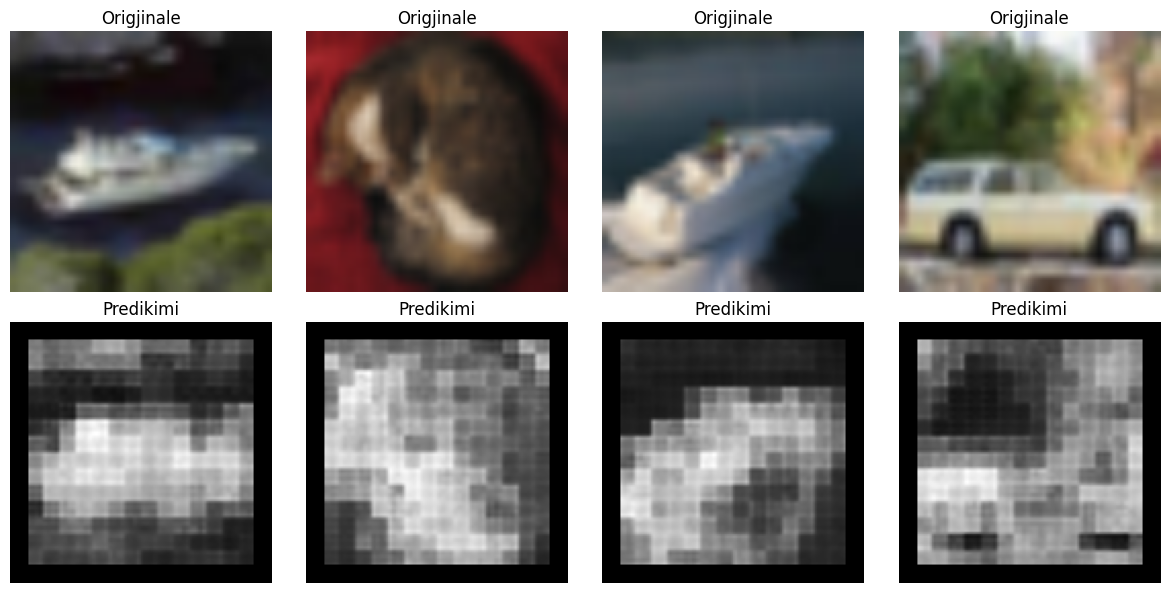

In [15]:
import matplotlib.pyplot as plt


images, _ = next(iter(trainloader))
images = images.to('cuda')


model.eval()
with torch.no_grad():
    preds = model(images)


plt.figure(figsize=(12, 6))
for i in range(4):

    plt.subplot(2, 4, i + 1)
    img = images[i].cpu().permute(1, 2, 0)
    plt.imshow(img)
    plt.title("Origjinale")
    plt.axis('off')


    plt.subplot(2, 4, i + 5)
    plt.imshow(preds[i].cpu().squeeze(), cmap='gray')
    plt.title("Predikimi")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

def final_evaluation(model, loader):
    model.eval()
    precisions, recalls, f1s, ious = [], [], [], []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to('cuda')
            targets = torch.zeros((images.size(0), 1, 128, 128)).to('cuda')
            targets[:, :, 32:96, 32:96] = 1.0

            outputs = model(images)
            preds = (outputs > 0.5).float().cpu().numpy().flatten()
            trues = targets.cpu().numpy().flatten()

            precisions.append(precision_score(trues, preds, zero_division=0))
            recalls.append(recall_score(trues, preds, zero_division=0))
            f1s.append(f1_score(trues, preds, zero_division=0))
            ious.append(calculate_metrics(outputs, targets))

    print("-" * 30)
    print(f"TABELA FINALE E REZULTATEVE")
    print("-" * 30)
    print(f"Precision: {np.mean(precisions):.4f}")
    print(f"Recall:    {np.mean(recalls):.4f}")
    print(f"F1-Score:  {np.mean(f1s):.4f}")
    print(f"IoU:       {np.mean(ious):.4f}")
    print("-" * 30)

final_evaluation(model, trainloader)

------------------------------
TABELA FINALE E REZULTATEVE
------------------------------
Precision: 0.5129
Recall:    0.3765
F1-Score:  0.4320
IoU:       0.2763
------------------------------
